# Public Library Survey (PLS) Data Analysis
This notebook explores the physical infrastructure, operational hours, and community reach of public libraries across the United States. 

## 1. Setup and Data Loading
We begin by importing the necessary libraries and loading our dataset to understand its basic structure.

In [47]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set the visual style for all plots
sns.set_theme(style="whitegrid")

# Load the dataset (using low_memory=False and latin-1 encoding to prevent read errors)
df = pd.read_csv("pls_fy18_outlet_pud18i.csv", encoding="latin-1", low_memory=False)

# Explore the shape and basic information of the dataset
print("=" * 45)
print("       DATA COLLECTION — OVERVIEW")
print("=" * 45)
print(f"  Total Rows    : {df.shape[0]:,}")
print(f"  Total Columns : {df.shape[1]}")
print(f"  File Year     : FY 2018")
print(f"  Source        : US Institute of Museum and Library Services")
print("=" * 45)
df.head()

       DATA COLLECTION — OVERVIEW
  Total Rows    : 17,478
  Total Columns : 37
  File Year     : FY 2018
  Source        : US Institute of Museum and Library Services


,STABR,FSCSKEY,FSCS_SEQ,C_FSCS,LIBID,LIBNAME,ADDRESS,CITY,ZIP,ZIP4,...,GNISPLAC,CNTYPOP,LOCALE,REAPLOCALE,CENTRACT,CENBLOCK,CDCODE,CBSA,MICROF,GEOMATCH
0,AK,AK0001,2,Y,AK0001-002,ANCHOR POINT PUBLIC LIBRARY,34020 NORTH FORK ROAD,ANCHOR POINT,99556,M,...,0203110,58533,43,7,8.00,3007,0200,-4,N,A
1,AK,AK0002,7,Y,AK0002-007,CHUGIAK-EAGLE RIVER LIBRARY,12001 BUSINESS BOULEVARD #176,EAGLE RIVER,99577,7743,...,0203000,291538,31,1,2.01,2021,0200,11260,0,A
2,AK,AK0002,8,Y,AK0002-008,MULDOON LIBRARY,"1251 MULDOON ROAD, SUITE 158",ANCHORAGE,99504,2012,...,0203000,291538,11,1,7.03,5012,0200,11260,0,A
3,AK,AK0002,10,Y,AK0002-010,SCOTT AND WESLEY GERRISH LIBRARY,250 EGLOFF DRIVE,GIRDWOOD,99587,M,...,0203000,291538,42,1,29.00,2050,0200,11260,0,A
4,AK,AK0002,11,Y,AK0002-011,Z. J. LOUSSAC LIBRARY,3600 DENALI STREET,ANCHORAGE,99503,6055,...,0203000,291538,11,1,19.00,3002,0200,11260,0,A


## 2. Initial Data Exploration
Before cleaning, we check the dataset for basic statistics, missing values, and unique counts to understand the quality of our data.

In [48]:
# ── Load the dataset ──────────────────────────────────────────
df = pd.read_csv("pls_fy18_outlet_pud18i.csv", encoding='latin1', low_memory=False)

print("=" * 45)
print("       DATA COLLECTION — OVERVIEW")
print("=" * 45)
print(f"  Total Rows    : {df.shape[0]:,}")
print(f"  Total Columns : {df.shape[1]}")
print(f"  File Year     : FY 2018")
print(f"  Source        : US Institute of Museum and Library Services")
print("=" * 45)

# ── Missing values per column ─────────────────────────────────
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("Columns with Missing Values:")
print("-" * 35)
print(missing.to_string())
print(f"Total columns with missing data: {len(missing)}")

# ── Basic statistics of numeric columns ──────────────────────
print("Basic Statistics of Key Columns:")
df[['SQ_FEET', 'HOURS', 'WKS_OPEN', 'CNTYPOP']].describe().round(2)

       DATA COLLECTION — OVERVIEW
  Total Rows    : 17,478
  Total Columns : 37
  File Year     : FY 2018
  Source        : US Institute of Museum and Library Services
Columns with Missing Values:
-----------------------------------
Series([], )
Total columns with missing data: 0
Basic Statistics of Key Columns:


,SQ_FEET,HOURS,WKS_OPEN,CNTYPOP
count,17478.00,17478.00,17478.00,17478.00
mean,12028.61,2108.21,50.21,621299.78
std,25315.76,882.38,8.56,1443922.03
min,-4.00,-3.00,-3.00,114.00
25%,2400.00,1549.25,52.00,32424.25
50%,6000.00,2236.00,52.00,126348.00
75%,13776.00,2756.00,52.00,576031.00
max,970000.00,5526.00,52.00,10105518.00


## 3. Data Cleaning and Feature Engineering
We need to clean the data by removing duplicates, filtering out invalid negative values, and mapping coded columns into readable categories for our charts.

In [49]:
print(f"Shape BEFORE cleaning : {df.shape}")

# 1. Filter out missing/negative values for our core metrics
df_clean = df[(df['SQ_FEET'] > 0) & (df['HOURS'] > 0) & (df['WKS_OPEN'] > 0)].copy()

# 1. Remove duplicate rows
df = df.drop_duplicates()
print(f"After removing duplicates : {df.shape[0]:,} rows")

# 2. Feature Engineering: Calculate Hours Open Per Week
df_clean['HOURS_PER_WEEK'] = df_clean['HOURS'] / df_clean['WKS_OPEN']
print(f"After removing invalid rows : {df.shape[0]:,} rows")

# 3. Map Outlet Types to readable names
outlet_map = {
    'CE': 'Central',
    'BR': 'Branch',
    'BS': 'Bookmobile',
    'MO': 'Books-by-Mail Only'
}
df_clean['OUTLET_TYPE'] = df_clean['C_OUT_TY'].map(outlet_map)

# 4. Map Locale Codes to broader categories (City, Suburb, Town, Rural)
def map_locale(code):
    if code in [11, 12, 13]: return 'City'
    elif code in [21, 22, 23]: return 'Suburb'
    elif code in [31, 32, 33]: return 'Town'
    elif code in [41, 42, 43]: return 'Rural'
    else: return 'Unknown'

df_clean['LOCALE_CAT'] = df_clean['LOCALE'].apply(map_locale)
print(f"Shape AFTER cleaning  : {df.shape}")
print("Data Cleaning Complete. Ready for Visualization!")

Shape BEFORE cleaning : (17478, 37)
After removing duplicates : 17,478 rows
After removing invalid rows : 17,478 rows
Shape AFTER cleaning  : (17478, 37)
Data Cleaning Complete. Ready for Visualization!


## 4. Executive Summary
With our data cleaned, here is a high-level executive summary of the US library system's core metrics and our key findings.

In [50]:
print("=" * 60)
print("        DATASET ANALYSIS SUMMARY")
print("=" * 60)

# Map the outlet types so they print nicely
outlet_map = {'CE': 'Central', 'BR': 'Branch', 'BS': 'Bookmobile', 'MO': 'Books-by-Mail Only'}
df['OUTLET_TYPE'] = df['C_OUT_TY'].map(outlet_map)

# Filter out negative placeholders just for the mathematical calculations 
valid_sq_feet = df[df['SQ_FEET'] > 0]['SQ_FEET']
valid_hours = df[df['HOURS'] > 0]['HOURS']
valid_wks = df[df['WKS_OPEN'] > 0]['WKS_OPEN']

print(f"  File Year     : FY 2018")
print(f"\nTotal Library Outlets Analyzed : {len(df):,}")
print(f"Total US States Covered        : {df['STABR'].nunique()}")
print(f"\nMost Common Outlet Type        : {df['OUTLET_TYPE'].value_counts().idxmax()}")
# Using Median for real estate size, formatted with a comma (e.g., 6,550)
print(f"Median Library Size (sq ft)    : {valid_sq_feet.median():,.0f} sq ft")
print(f"Avg Hours Open Per Year        : {valid_hours.mean():,.0f} hours")
print(f"Avg Weeks Open Per Year        : {valid_wks.mean():.1f} weeks")

print("\n--- Top 3 Most Library-Dense States ---")
print(df['STABR'].value_counts().head(3).to_string())

print("\n--- Outlet Type Breakdown ---")
print(df['OUTLET_TYPE'].value_counts().to_string())

print("  Key Findings:")
print("  1. Branch + Central Libraries = 94% of all US library outlets")
print("  2. Suburban areas have the most library outlets overall")
print("  3. City libraries are larger AND open more hours")
print("  4. County population positively predicts library operating hours")
print("  5. Size and hours are statistically significantly correlated")
print("  6. Most libraries (82%+) operate 52 weeks a year — full year access")
print("=" * 58)

print("\n✅ Analysis Complete!")

        DATASET ANALYSIS SUMMARY
  File Year     : FY 2018

Total Library Outlets Analyzed : 17,478
Total US States Covered        : 55

Most Common Outlet Type        : Central
Median Library Size (sq ft)    : 6,550 sq ft
Avg Hours Open Per Year        : 2,174 hours
Avg Weeks Open Per Year        : 51.4 weeks

--- Top 3 Most Library-Dense States ---
STABR
CA    1225
NY    1080
TX     896

--- Outlet Type Breakdown ---
OUTLET_TYPE
Central               9092
Branch                7757
Bookmobile             628
Books-by-Mail Only       1
  Key Findings:
  1. Branch + Central Libraries = 94% of all US library outlets
  2. Suburban areas have the most library outlets overall
  3. City libraries are larger AND open more hours
  4. County population positively predicts library operating hours
  5. Size and hours are statistically significantly correlated
  6. Most libraries (82%+) operate 52 weeks a year — full year access

✅ Analysis Complete!


## 5. Visualizing Library Outlet Types
What kinds of libraries make up the system? These charts show the split between Central, Branch, and Mobile libraries.

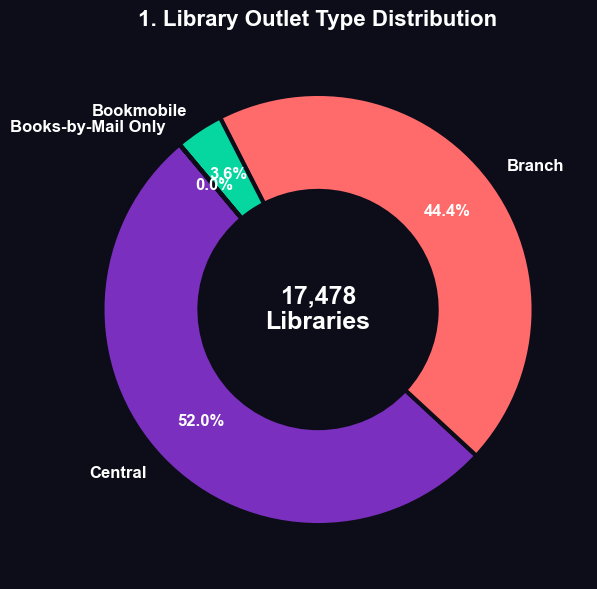

In [51]:
# ── SHORT & ELEGANT DONUT CHART ──────────────────────────
counts = df['OUTLET_TYPE'].value_counts()
colors = ['#7B2FBE', '#FF6B6B', '#06D6A0', '#FF9F45']

# Create figure with the dark background color
fig, ax = plt.subplots(figsize=(7, 7), facecolor='#0d0d1a')

# Plot the pie chart. 
# 'textprops' handles all text formatting automatically (no loops needed!)
ax.pie(counts, labels=counts.index, autopct='%1.1f%%', colors=colors, 
       startangle=130, pctdistance=0.75, 
       wedgeprops={'width': 0.45, 'edgecolor': '#0d0d1a', 'linewidth': 3},
       textprops={'color': 'white', 'fontsize': 12, 'fontweight': 'bold'})

# Add the center text and title
ax.text(0, 0, f"{len(df):,}\nLibraries", ha='center', va='center', color='white', fontsize=18, fontweight='bold')
plt.title("1. Library Outlet Type Distribution", color='white', fontsize=16, fontweight='bold', pad=10)

plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_20356\663170143.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_clean, x='OUTLET_TYPE', palette='viridis', order=order)


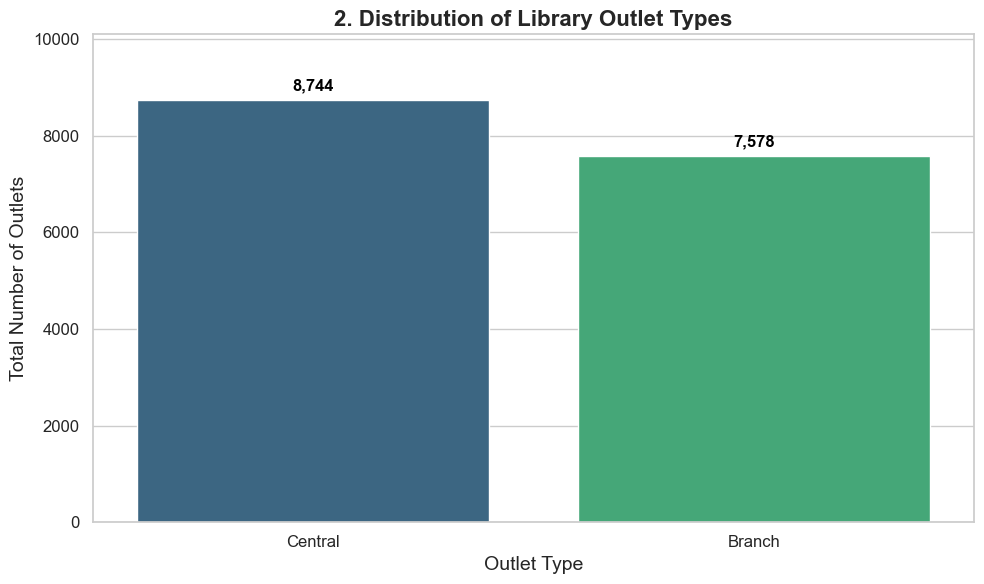

In [52]:
# Create the figure with a slightly larger size for a better presentation layout
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Get the order of the categories so it sorts from highest to lowest
order = df_clean['OUTLET_TYPE'].value_counts().index

# Generate the bar chart
ax = sns.countplot(data=df_clean, x='OUTLET_TYPE', palette='viridis', order=order)

# ENHANCEMENT: Add the exact numbers (data labels) on top of the bars
for container in ax.containers:
    # Format the numbers to include commas (e.g., 9,058 instead of 9058) for readability
    labels = [f'{int(v.get_height()):,}' for v in container]
    ax.bar_label(container, labels=labels, padding=5, fontsize=12,
                 fontweight='bold', color='black')

# Improve fonts and titles for better readability
plt.title('2. Distribution of Library Outlet Types', fontsize=16, fontweight='bold')
plt.xlabel('Outlet Type', fontsize=14)
plt.ylabel('Total Number of Outlets', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Expand the y-axis slightly (by 10%) so the numbers don't touch the top edge of the graph
plt.ylim(0, ax.get_ylim()[1] * 1.1)

plt.tight_layout()
plt.show()

## 6. Geographic Distribution
Looking at where these libraries are located, both by state volume and by urban/rural locale settings.

C:\Users\hp\AppData\Local\Temp\ipykernel_20356\73123206.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(x=top_states.values, y=top_states.index, palette='magma')


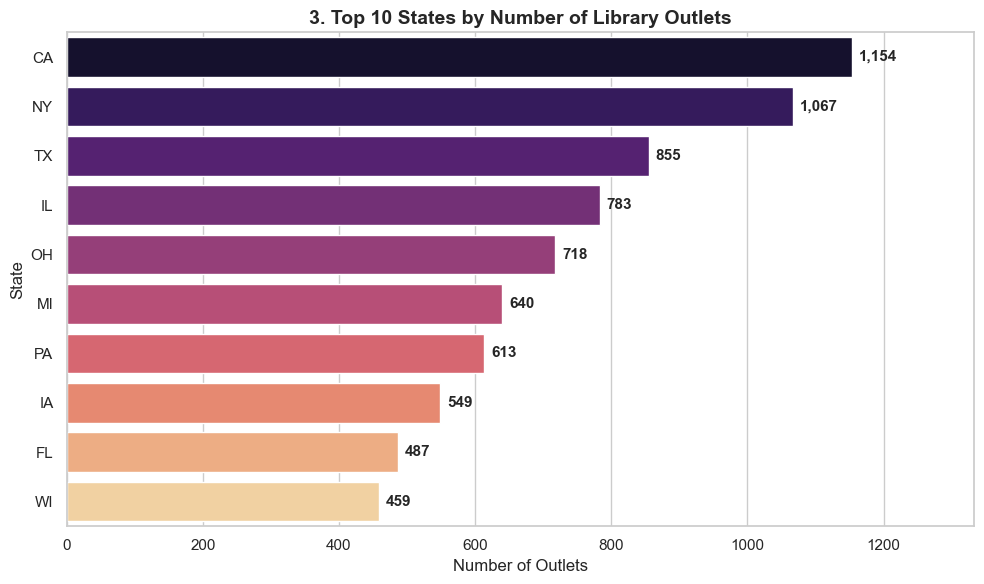

In [53]:
plt.figure(figsize=(10, 6))
top_states = df_clean['STABR'].value_counts().head(10)

ax2 = sns.barplot(x=top_states.values, y=top_states.index, palette='magma')

# Add exact numbers next to the horizontal bars
for container in ax2.containers:
    labels = [f'{int(v.get_width()):,}' for v in container]
    ax2.bar_label(container, labels=labels, padding=5, fontsize=11, fontweight='bold')

plt.title('3. Top 10 States by Number of Library Outlets', fontsize=14, fontweight='bold')
plt.xlabel('Number of Outlets', fontsize=12)
plt.ylabel('State', fontsize=12)

# Expand the x-axis slightly so the numbers don't get cut off
plt.xlim(0, ax2.get_xlim()[1] * 1.1)
plt.tight_layout()
plt.show()

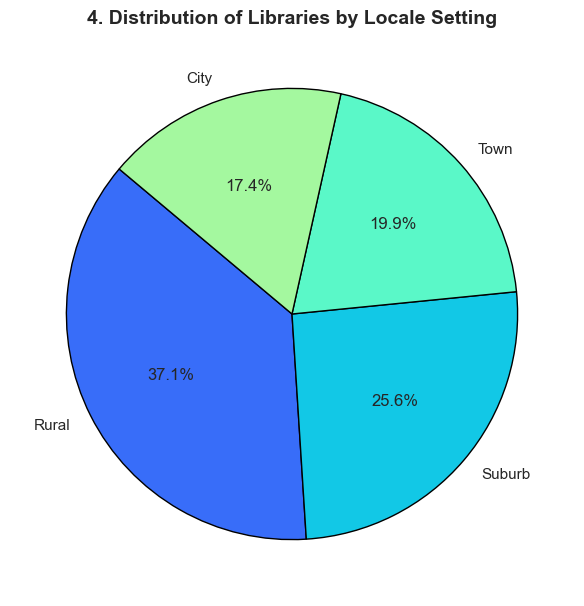

In [75]:
plt.figure(figsize=(6, 7))
locale_counts = df_clean['LOCALE_CAT'].value_counts()
plt.pie(locale_counts, labels=locale_counts.index, autopct='%1.1f%%',
        startangle=140, colors=sns.color_palette('rainbow'),
        wedgeprops={'edgecolor': 'black'})
plt.title('4. Distribution of Libraries by Locale Setting', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

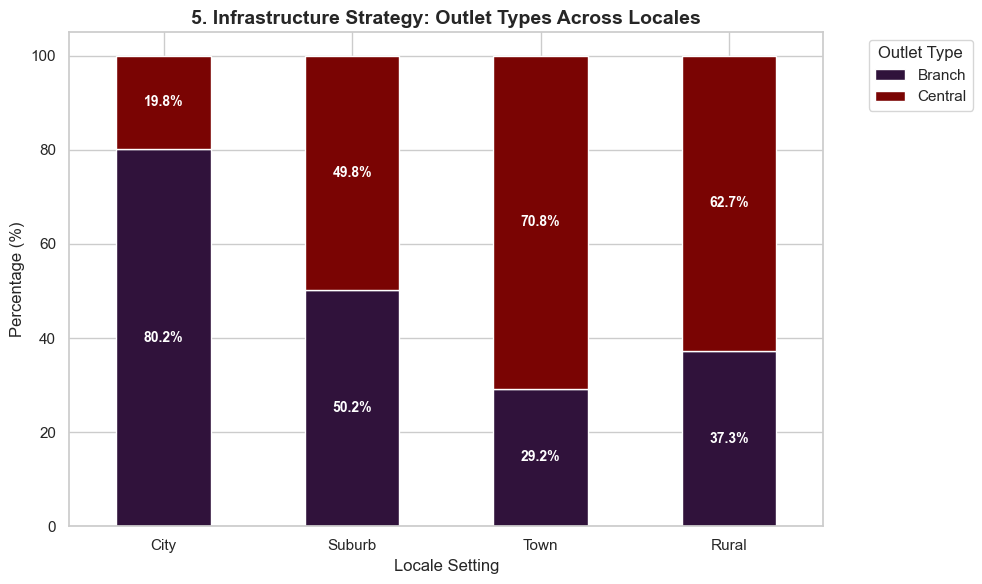

In [55]:
# Calculate percentages
cross_tab = pd.crosstab(df_clean['LOCALE_CAT'], df_clean['OUTLET_TYPE'], normalize='index') * 100
cross_tab = cross_tab.reindex(['City', 'Suburb', 'Town', 'Rural'])

# Plot stacked bar chart
ax10 = cross_tab.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='turbo')

# Add percentages in the center of the stacked bars
for container in ax10.containers:
    # We use an 'if' statement to hide labels for tiny sections (like Books-by-Mail)
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 3 else '' for v in container]
    ax10.bar_label(container, labels=labels, label_type='center', 
                   color='white', fontweight='bold', fontsize=10)

plt.title('5. Infrastructure Strategy: Outlet Types Across Locales', fontsize=14, fontweight='bold')
plt.xlabel('Locale Setting', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.legend(title='Outlet Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Analyzing Library Size and Operating Hours
How large are these physical spaces, and how many hours do they operate? We explore the distributions, averages, and densities.

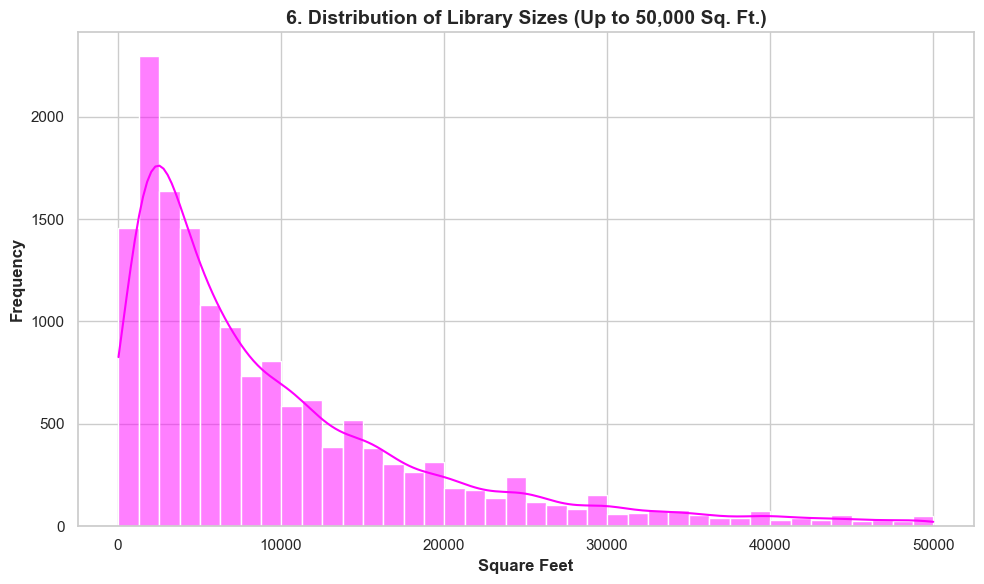

In [83]:
plt.figure(figsize=(10, 6))
# Filtering out massive outliers (>50k sq ft) just to see the main distribution clearly
sns.histplot(df_clean[df_clean['SQ_FEET'] <= 50000]['SQ_FEET'], bins=40, color='fuchsia', kde=True)
plt.title('6. Distribution of Library Sizes (Up to 50,000 Sq. Ft.)', fontsize=14, fontweight='bold')
plt.xlabel('Square Feet', fontsize=12,fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

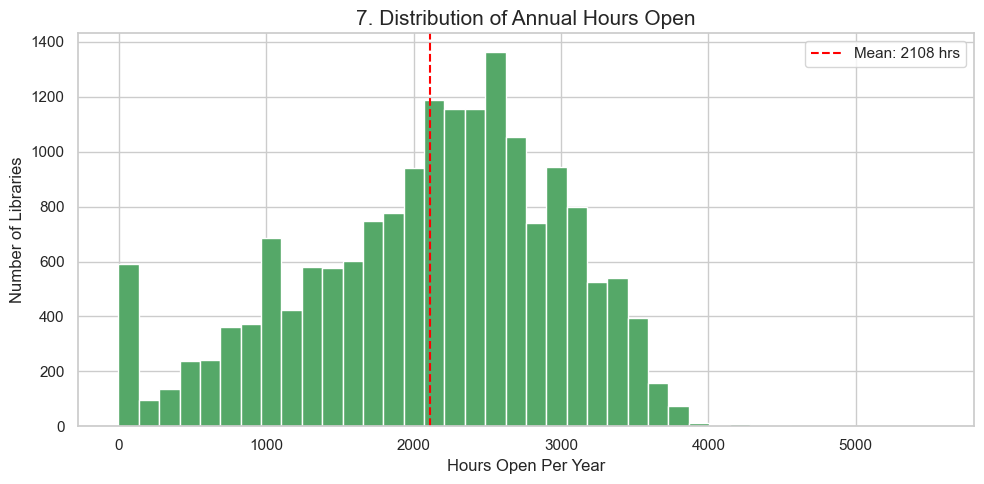


📊 Insight: Most libraries are open 1,500–3,000 hours/year.
Mean: 2108 hours | Max: 5526 hours


In [57]:
plt.figure(figsize=(10, 5))
plt.hist(df['HOURS'], bins=40, color='#55A868', edgecolor='white')
plt.title("7. Distribution of Annual Hours Open", fontsize=15)
plt.xlabel("Hours Open Per Year")
plt.ylabel("Number of Libraries")
plt.axvline(df['HOURS'].mean(), color='red', linestyle='--',
            label=f'Mean: {df["HOURS"].mean():.0f} hrs')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\n📊 Insight: Most libraries are open 1,500–3,000 hours/year.")
print(f"Mean: {df['HOURS'].mean():.0f} hours | Max: {df['HOURS'].max()} hours")

C:\Users\hp\AppData\Local\Temp\ipykernel_20356\3006715828.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax4 = sns.barplot(data=avg_hours, x='OUTLET_TYPE', y='HOURS_PER_WEEK', palette='coolwarm')


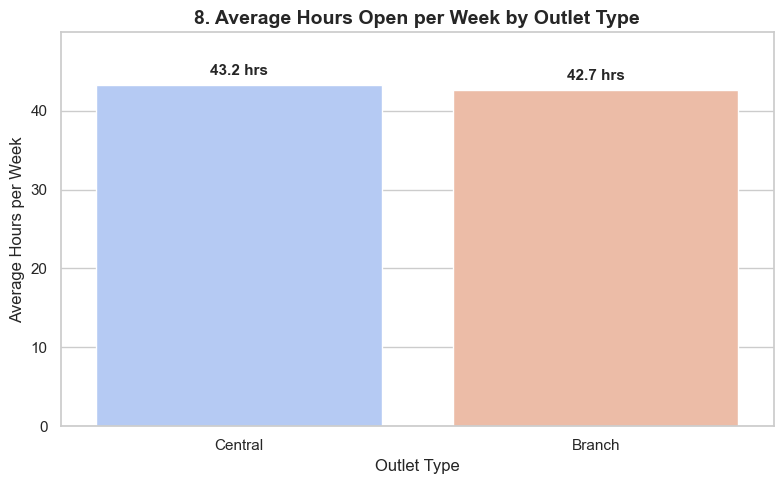

In [58]:
plt.figure(figsize=(8, 5))
avg_hours = df_clean.groupby('OUTLET_TYPE')['HOURS_PER_WEEK'].mean().reset_index().sort_values(by='HOURS_PER_WEEK', ascending=False)

ax4 = sns.barplot(data=avg_hours, x='OUTLET_TYPE', y='HOURS_PER_WEEK', palette='coolwarm')

# Add the exact average hours on top of the bars
for container in ax4.containers:
    labels = [f'{v.get_height():.1f} hrs' for v in container]
    ax4.bar_label(container, labels=labels, padding=5, fontsize=11, fontweight='bold')

plt.title('8. Average Hours Open per Week by Outlet Type', fontsize=14, fontweight='bold')
plt.xlabel('Outlet Type', fontsize=12)
plt.ylabel('Average Hours per Week', fontsize=12)

# Expand the y-axis slightly for the labels
plt.ylim(0, ax4.get_ylim()[1] * 1.1)
plt.tight_layout()
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_20356\3084125949.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean[df_clean['SQ_FEET'] <= 50000],


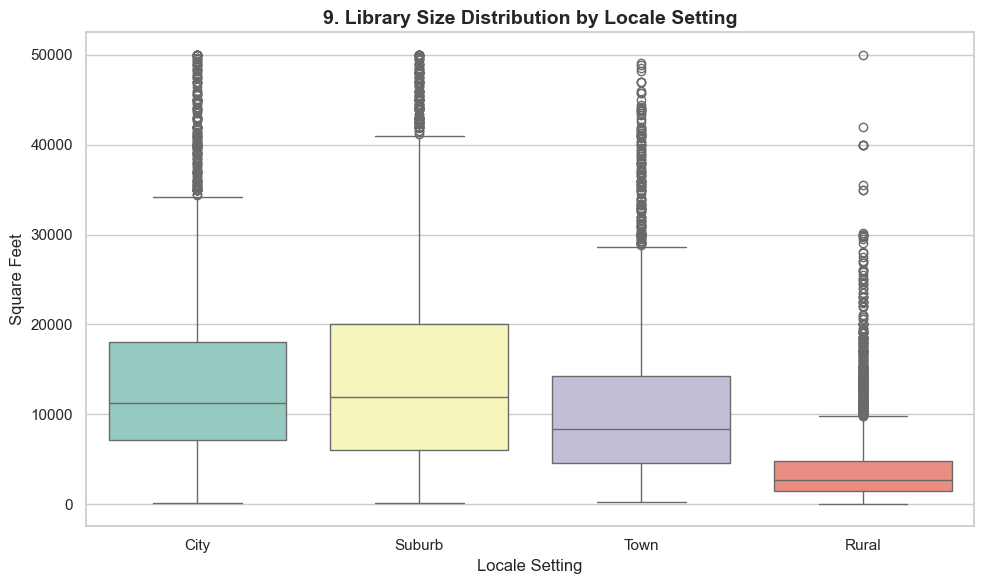

In [59]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean[df_clean['SQ_FEET'] <= 50000],
            x='LOCALE_CAT', y='SQ_FEET', palette='Set3',
            order=['City', 'Suburb', 'Town', 'Rural'])
plt.title('9. Library Size Distribution by Locale Setting', fontsize=14, fontweight='bold')
plt.xlabel('Locale Setting', fontsize=12)
plt.ylabel('Square Feet', fontsize=12)
plt.tight_layout()
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_20356\2558019893.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_clean[df_clean['OUTLET_TYPE'] != 'Books-by-Mail Only'],


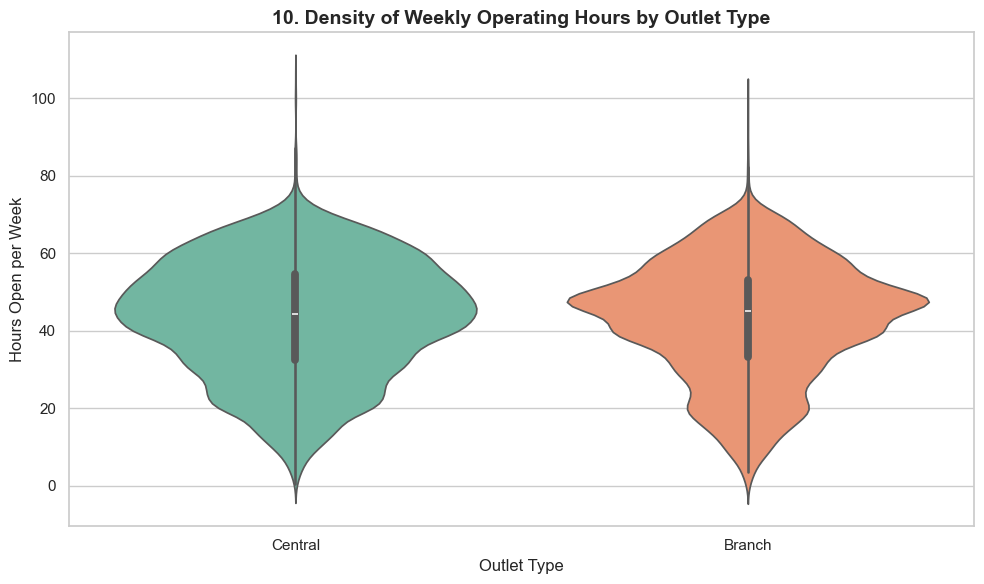

In [60]:
plt.figure(figsize=(10, 6))

# We filter out "Books-by-Mail" here because it only has 1 record in the dataset
sns.violinplot(data=df_clean[df_clean['OUTLET_TYPE'] != 'Books-by-Mail Only'],
               x='OUTLET_TYPE', y='HOURS_PER_WEEK', palette='Set2')

plt.title('10. Density of Weekly Operating Hours by Outlet Type', fontsize=14, fontweight='bold')
plt.xlabel('Outlet Type', fontsize=12)
plt.ylabel('Hours Open per Week', fontsize=12)
plt.tight_layout()
plt.show()

## 8. Correlations and Predictive Trends
Finally, we analyze how population, physical size, and operating hours correlate with one another to find actionable trends for infrastructure planning.

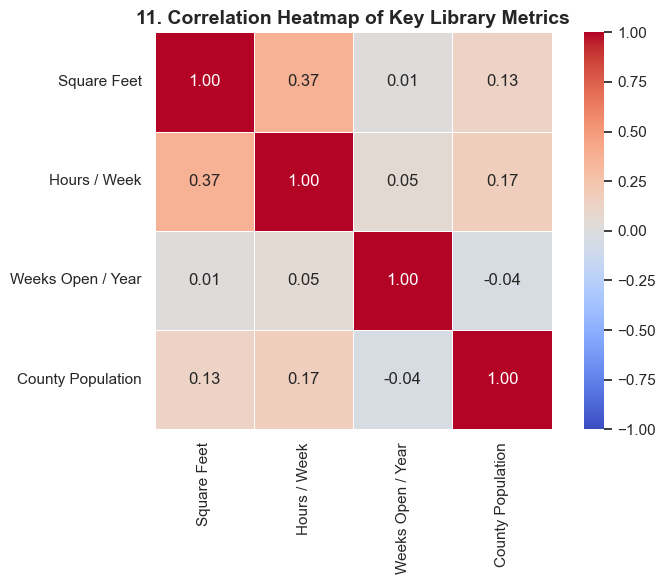

In [61]:
# Select the most suitable numerical columns for correlation
num_cols = ['SQ_FEET', 'HOURS_PER_WEEK', 'WKS_OPEN', 'CNTYPOP']

# Rename them so the labels on the heatmap look professional and are easy to read
rename_dict = {
    'SQ_FEET': 'Square Feet',
    'HOURS_PER_WEEK': 'Hours / Week',
    'WKS_OPEN': 'Weeks Open / Year',
    'CNTYPOP': 'County Population'
}

# Create a subset dataframe and calculate the correlation matrix
corr_df = df_clean[num_cols].rename(columns=rename_dict)
corr_matrix = corr_df.corr()

# 8. Plot the Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1,
            fmt=".2f", linewidths=0.5, square=True)

plt.title('11. Correlation Heatmap of Key Library Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

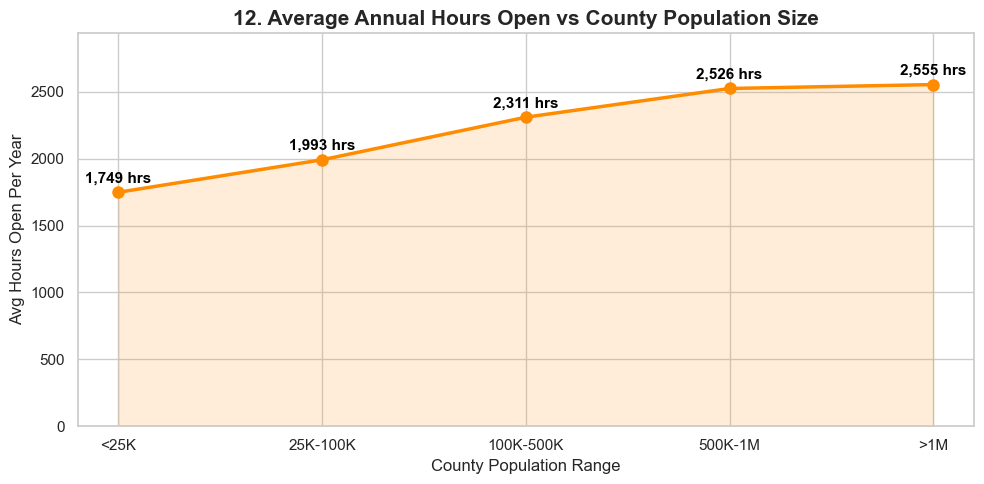


📊 Insight: Libraries in more populated counties are open more hours.
Larger communities have greater demand, driving longer operating hours.


In [62]:
# Bin county population into 5 groups
df['POP_BUCKET'] = pd.cut(df['CNTYPOP'],
                           bins=[0, 25000, 100000, 500000, 1000000, 10000000],
                           labels=['<25K','25K-100K','100K-500K','500K-1M','>1M'])

# Filter out missing/negative hours for accurate math!
valid_df = df[df['HOURS'] > 0]
pop_hours = valid_df.groupby('POP_BUCKET', observed=True)['HOURS'].mean()

plt.figure(figsize=(10, 5))
plt.plot(pop_hours.index, pop_hours.values, marker='o', color='darkorange',
         linewidth=2.5, markersize=8)
plt.fill_between(range(len(pop_hours)), pop_hours.values, alpha=0.15, color='darkorange')

# --- NEW: Add the exact numbers on top of the points ---
for i, value in enumerate(pop_hours.values):
    plt.text(i, value + 50, f"{value:,.0f} hrs", ha='center', va='bottom', 
             fontsize=11, fontweight='bold', color='black')

plt.title("12. Average Annual Hours Open vs County Population Size", fontsize=15, fontweight='bold')
plt.xlabel("County Population Range", fontsize=12)
plt.ylabel("Avg Hours Open Per Year", fontsize=12)

# Expand y-axis slightly from 0 to just above the max value so labels fit nicely
plt.ylim(0, max(pop_hours.values) * 1.15)
plt.xticks(range(len(pop_hours)), pop_hours.index)

plt.tight_layout()
plt.show()

print("\n📊 Insight: Libraries in more populated counties are open more hours.")
print("Larger communities have greater demand, driving longer operating hours.")

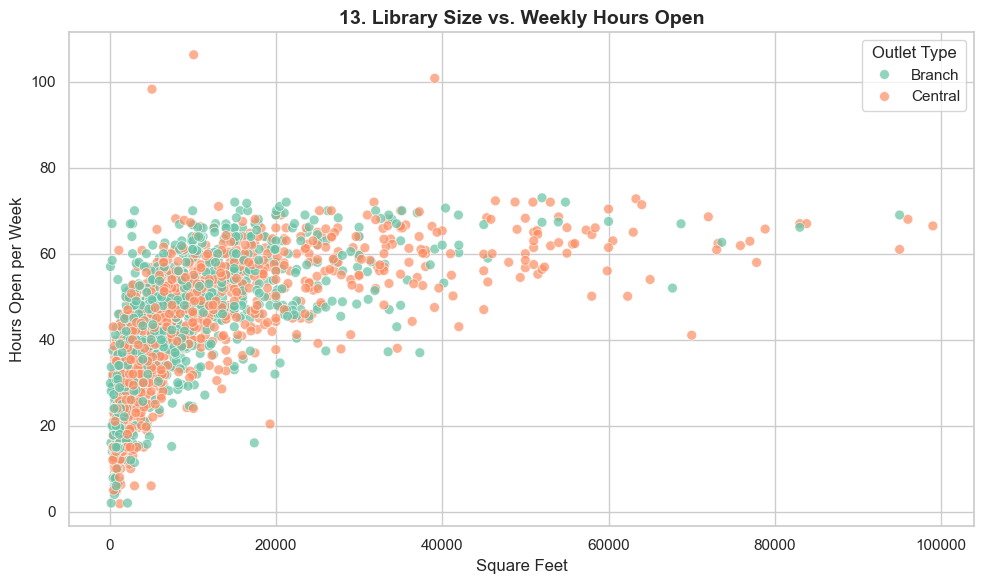

In [63]:
plt.figure(figsize=(10, 6))
# Taking a random sample of 2000 so the dots don't look too messy
sample_df = df_clean[df_clean['SQ_FEET'] <= 100000].sample(n=2000, random_state=42)

sns.scatterplot(data=sample_df, x='SQ_FEET', y='HOURS_PER_WEEK',
                hue='OUTLET_TYPE', palette='Set2', alpha=0.7, s=50)
plt.title('13. Library Size vs. Weekly Hours Open', fontsize=14, fontweight='bold')
plt.xlabel('Square Feet', fontsize=12)
plt.ylabel('Hours Open per Week', fontsize=12)
plt.legend(title='Outlet Type')
plt.tight_layout()
plt.show()

Defaulting to user installation because normal site-packages is not writeable


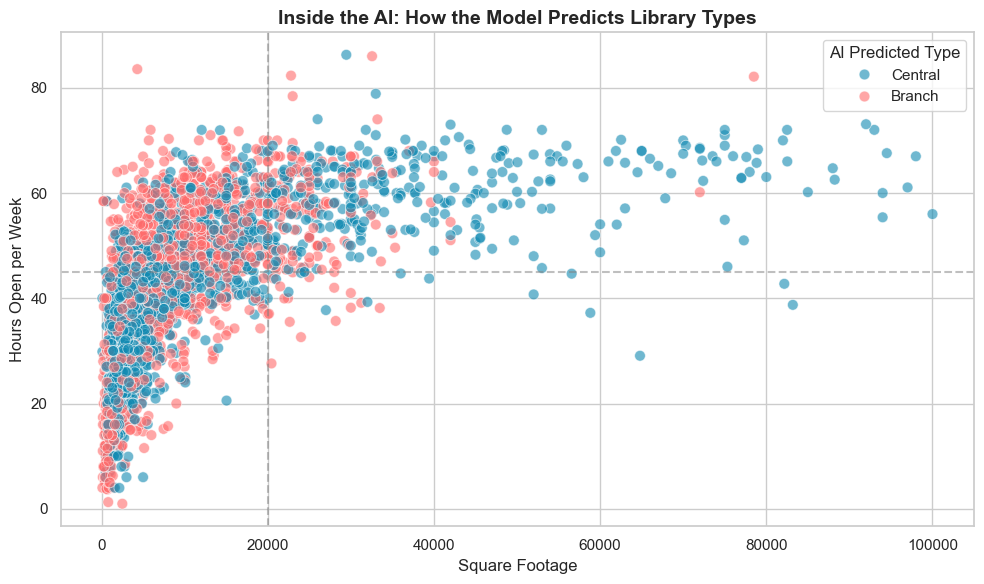

📌 Insight: The AI visually separates the libraries into distinct zones.
The blue cluster (Central hubs) overwhelmingly dominates the upper right (larger size + more hours),
while the red cluster (Branches) dominates the bottom left.


In [87]:
!pip install scikit-learn
# Import necessary ML libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1. Prepare Data for Classification
class_df = df_clean[df_clean['OUTLET_TYPE'].isin(['Central', 'Branch'])].copy()

features = ['SQ_FEET', 'HOURS_PER_WEEK', 'CNTYPOP', 'LOCALE_CAT']
target = 'OUTLET_TYPE'

X_class = class_df[features]
y_class = class_df[target]

# 2. Preprocessing Data
categorical_features = ['LOCALE_CAT']
numeric_features = ['SQ_FEET', 'HOURS_PER_WEEK', 'CNTYPOP']

class_preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ])

# 3. Create and Train the Classifier Pipeline
clf_model = Pipeline(steps=[
    ('preprocessor', class_preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, 
                                          max_depth=10, class_weight='balanced'))
])

# THIS LINE FIXES THE ERROR: We create X_test_c here!
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42, stratify=y_class
)

# Train the Model and Predict
clf_model.fit(X_train_c, y_train_c)
y_pred_c = clf_model.predict(X_test_c)

# ---------------------------------------------------------
# 4. VISUALIZATION: The Prediction Scatter Plot
# ---------------------------------------------------------

# Create a new dataframe with the test data and the model's predictions
viz_df = X_test_c.copy()
viz_df['Actual_Type'] = y_test_c
viz_df['Predicted_Type'] = y_pred_c

# Zoom in on libraries under 100,000 sq ft for readability
zoom_df = viz_df[viz_df['SQ_FEET'] <= 100000]

plt.figure(figsize=(10, 6))

# Plot the predicted categories
sns.scatterplot(data=zoom_df, x='SQ_FEET', y='HOURS_PER_WEEK', 
                hue='Predicted_Type', palette={'Branch': '#FF6B6B', 'Central': '#118AB2'}, 
                alpha=0.6, s=60)

# Add visual quadrant lines to represent the "Decision Boundary"
plt.axvline(x=20000, color='gray', linestyle='--', alpha=0.5)
plt.axhline(y=45, color='gray', linestyle='--', alpha=0.5)

plt.title('Inside the AI: How the Model Predicts Library Types', fontsize=14, fontweight='bold')
plt.xlabel('Square Footage', fontsize=12)
plt.ylabel('Hours Open per Week', fontsize=12)
plt.legend(title='AI Predicted Type')

plt.tight_layout()
plt.show()

print("📌 Insight: The AI visually separates the libraries into distinct zones.")
print("The blue cluster (Central hubs) overwhelmingly dominates the upper right (larger size + more hours),")
print("while the red cluster (Branches) dominates the bottom left.")

The Machine Learning classification model does the exact same thing, but takes it one step further. It looks at your scatter plot and asks: "Can a machine automatically draw a mathematical line to separate the blue dots from the red dots?"

First, the scatter plot: "Here is the raw data. As you can see, the Central Hubs (one color) tend to cluster higher and further to the right than the Branches."

Then, the ML model: "Because this visual pattern was so strong, we trained a Random Forest AI. The AI successfully learned how to draw a 'Decision Boundary' so it can instantly predict if a new building is a Branch or a Central Hub just by looking at its size and hours."

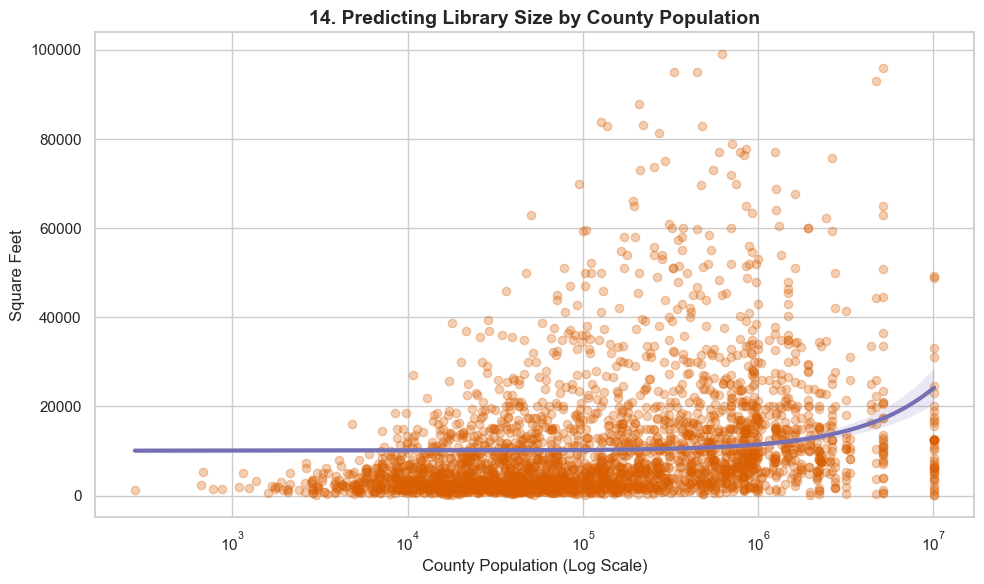

In [64]:
plt.figure(figsize=(10, 6))

# Take a sample to prevent the dots from turning into a solid unreadable block of color
sample_df = df_clean[(df_clean['CNTYPOP'] > 0) & (df_clean['SQ_FEET'] <= 100000)].sample(n=3000, random_state=42)

# Create the scatter plot with a linear regression line
sns.regplot(data=sample_df, x='CNTYPOP', y='SQ_FEET',
            scatter_kws={'alpha':0.3, 'color':'#d95f02'},
            line_kws={'color':'#7570b3', 'linewidth':3})

# Use a logarithmic scale for the X-axis because county populations range from 1,000 to 10,000,000
plt.xscale('log')

plt.title('14. Predicting Library Size by County Population', fontsize=14, fontweight='bold')
plt.xlabel('County Population (Log Scale)', fontsize=12)
plt.ylabel('Square Feet', fontsize=12)
plt.tight_layout()
plt.show()